# Города России: концентрация населения и сегментация
Анализ 1117 городов России , где сосредоточено городское население, чем различаются федеральные округа и на какие естественные группы делятся города.

Данные: реальные, из публикации Rosstat «Регионы России. Основные социально-экономические показатели городов» (население, координаты, регион, федеральный округ). Источник и ссылки будут представлены в конце ноутбука.

Содержание ноутбука : очистка данных · агрегации · анализ распределения · кластеризация (KMeans) · геовизуализация · выводы.


## 0. Оформление графиков

In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt


plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25,
    "axes.titlesize": 13, "axes.titleweight": "bold",
})
PALETTE = ["#1f3a5f", "#c96f4a", "#6a8d73", "#b0a08f"]

## 1. Загрузка данных

In [ ]:
df = pd.read_csv("towns.csv")
df = df[["city","population","lat","lon","region_name","federal_district"]]
print("строк:", len(df))
df.head()

строк: 1117


,city,population,lat,lon,region_name,federal_district
0,Алейск,29.0,52.492251,82.779361,Алтайский край,Сибирский
1,Барнаул,632.4,53.347997,83.779806,Алтайский край,Сибирский
2,Белокуриха,15.2,51.996152,84.983960,Алтайский край,Сибирский
3,Бийск,199.5,52.539386,85.213845,Алтайский край,Сибирский
4,Горняк,12.3,50.997962,81.464336,Алтайский край,Сибирский


## 2. Чистка

In [ ]:

before = len(df)
df = df.dropna(subset=["population","lat","lon"]).reset_index(drop=True)
print(f"убрано строк с пропусками: {before - len(df)} | осталось: {len(df)}")

убрано строк с пропусками: 0 | осталось: 1117


## 3. Концентрация населения

In [ ]:
total = df["population"].sum()
top10 = df.sort_values("population", ascending=False).head(10)
top2_share  = top10["population"].head(2).sum() / total * 100
top10_share = top10["population"].sum() / total * 100

print(f"городов: {len(df)} | суммарное городское население: {total:,.0f} тыс.")
print(f"доля Москвы и Санкт-Петербурга: {top2_share:.1f}%")
print(f"доля топ-10 городов: {top10_share:.1f}%")
print(f"медианный город: {df['population'].median():.0f} тыс. | средний: {df['population'].mean():.0f} тыс.")
top10[["city","population","federal_district"]]

городов: 1117 | суммарное городское население: 102,820 тыс.
доля Москвы и Санкт-Петербурга: 17.5%
доля топ-10 городов: 27.5%
медианный город: 26 тыс. | средний: 92 тыс.


,city,population,federal_district
412,Москва,12655.1,Центральный
839,Санкт-Петербург,5384.3,Северо-Западный
549,Новосибирск,1625.6,Сибирский
885,Екатеринбург,1493.7,Уральский
771,Казань,1257.4,Приволжский
521,Нижний Новгород,1252.2,Приволжский
1085,Челябинск,1196.7,Уральский
835,Самара,1156.7,Приволжский
558,Омск,1154.5,Сибирский
810,Ростов-на-Дону,1137.9,Южный


Медиана (≈26 тыс.) намного меньше среднего (≈92 тыс.) что показывает перевес на правом хвосте распределения, по факту наличие китов : немного городов-гигантов и очень много малых. Посмотрим на распределение.

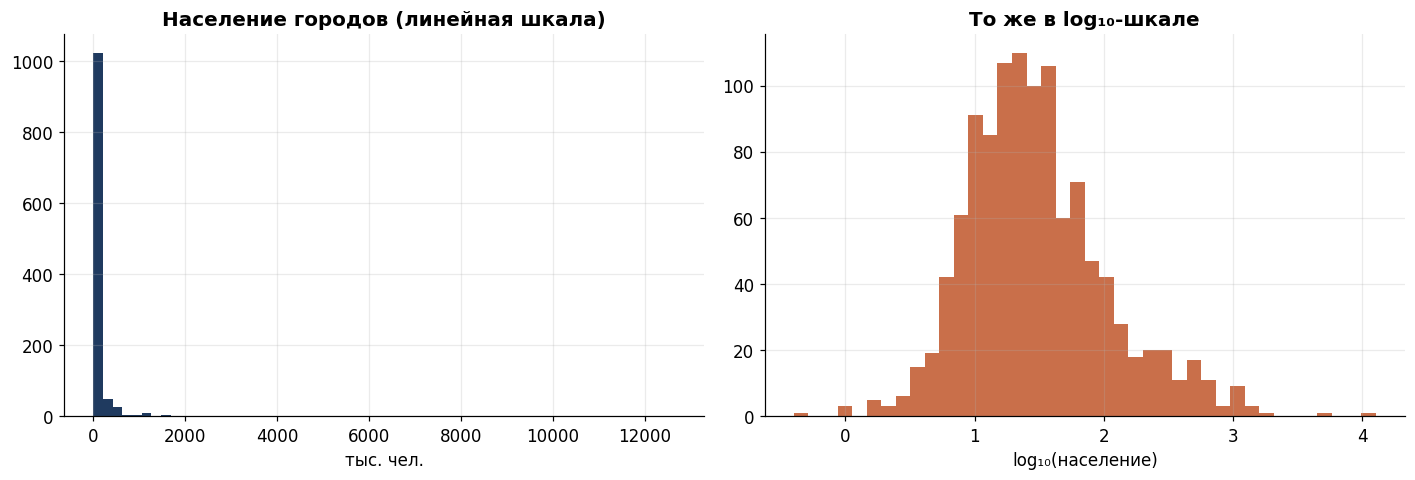

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
ax[0].hist(df["population"], bins=60, color=PALETTE[0])
ax[0].set_title("Население городов (линейная шкала)"); ax[0].set_xlabel("тыс. чел.")
# в лог-шкале перекос выпрямляется и распределение близко к логнормальному
ax[1].hist(np.log10(df["population"]), bins=40, color=PALETTE[1])
ax[1].set_title("То же в log₁₀-шкале"); ax[1].set_xlabel("log₁₀(население)")
plt.tight_layout(); plt.show()

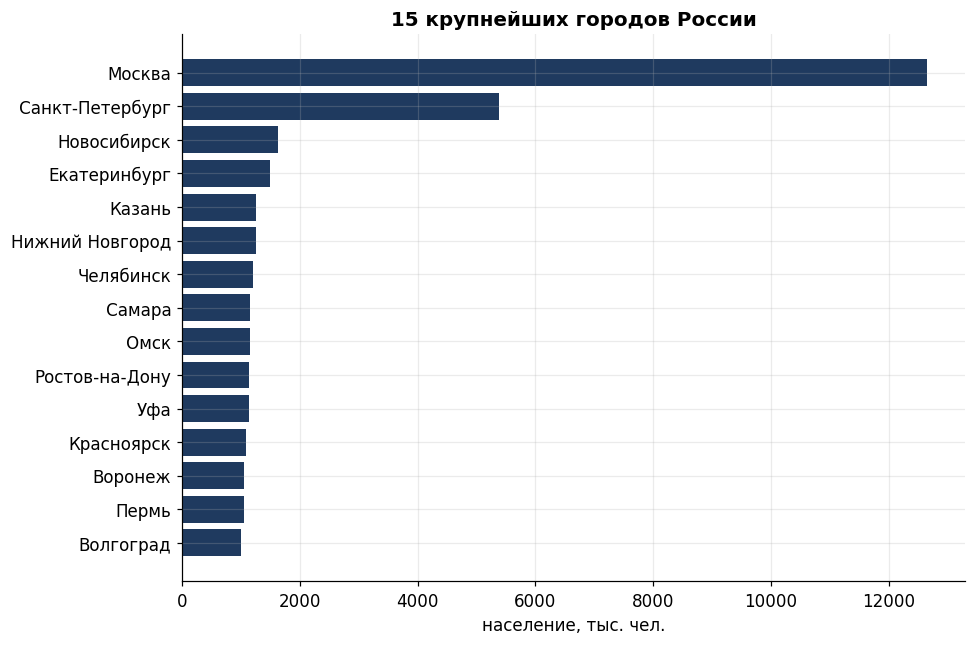

In [ ]:
top15 = df.sort_values("population", ascending=False).head(15)
plt.figure(figsize=(9,6))
plt.barh(top15["city"][::-1], top15["population"][::-1], color=PALETTE[0])
plt.title("15 крупнейших городов России"); plt.xlabel("население, тыс. чел.")
plt.tight_layout(); plt.show()

## 4. Сравнение федеральных округов

In [ ]:
fo = (df.groupby("federal_district")
        .agg(городов=("city","size"),
             население_тыс=("population","sum"),
             средний_город=("population","mean"))
        .sort_values("население_тыс", ascending=False).round(1))
fo

,городов,население_тыс,средний_город
federal_district,,,
Центральный,304,30819.9,101.4
Приволжский,200,19713.7,98.6
Сибирский,114,11680.5,102.5
Северо-Западный,148,11213.1,75.8
Южный,96,9991.4,104.1
Уральский,115,9599.6,83.5
Дальневосточный,82,5114.5,62.4
Северо-Кавказский,58,4687.3,80.8


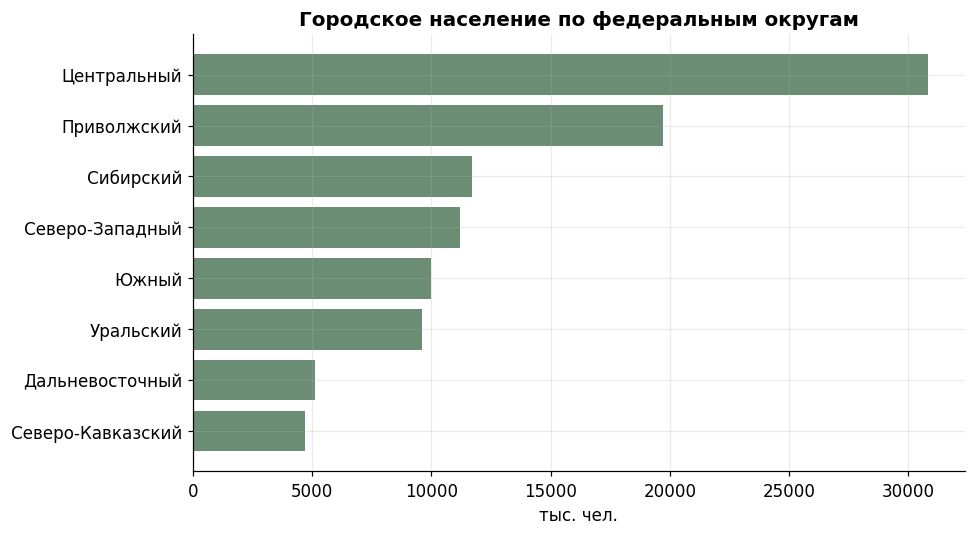

In [ ]:
plt.figure(figsize=(9,5))
plt.barh(fo.index[::-1], fo["население_тыс"][::-1], color=PALETTE[2])
plt.title("Городское население по федеральным округам"); plt.xlabel("тыс. чел.")
plt.tight_layout(); plt.show()

## 5. Сегментация городов (KMeans)
Разобьём города на группы по профилю **размер + география**. Население берём в log-шкале: иначе Москва и Петербург как выбросы «перетянут» кластеры на себя (выбросы просто сломают модель)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df["log_pop"] = np.log10(df["population"])
X = StandardScaler().fit_transform(df[["log_pop","lat","lon"]])

### Сколько брать кластеров — метод локтя

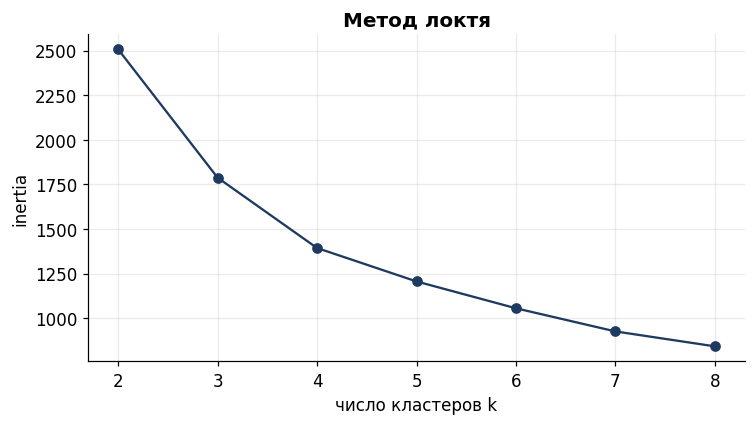

In [ ]:
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X).inertia_ for k in range(2,9)]
plt.figure(figsize=(7,4))
plt.plot(range(2,9), inertias, "o-", color=PALETTE[0])
plt.xlabel("число кластеров k"); plt.ylabel("inertia"); plt.title("Метод локтя")
plt.tight_layout(); plt.show()

In [ ]:
df["cluster"] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X)

profile = (df.groupby("cluster")
             .agg(городов=("city","size"),
                  ср_население=("population","mean"),
                  ср_широта=("lat","mean"),
                  ср_долгота=("lon","mean")).round(1))
profile

,городов,ср_население,ср_широта,ср_долгота
cluster,,,,
0,228,312.7,55.9,49.5
1,546,18.3,57.0,43.9
2,167,50.8,53.5,111.4
3,176,74.0,46.3,41.9


### Карта: города в координатах, цвет — кластер

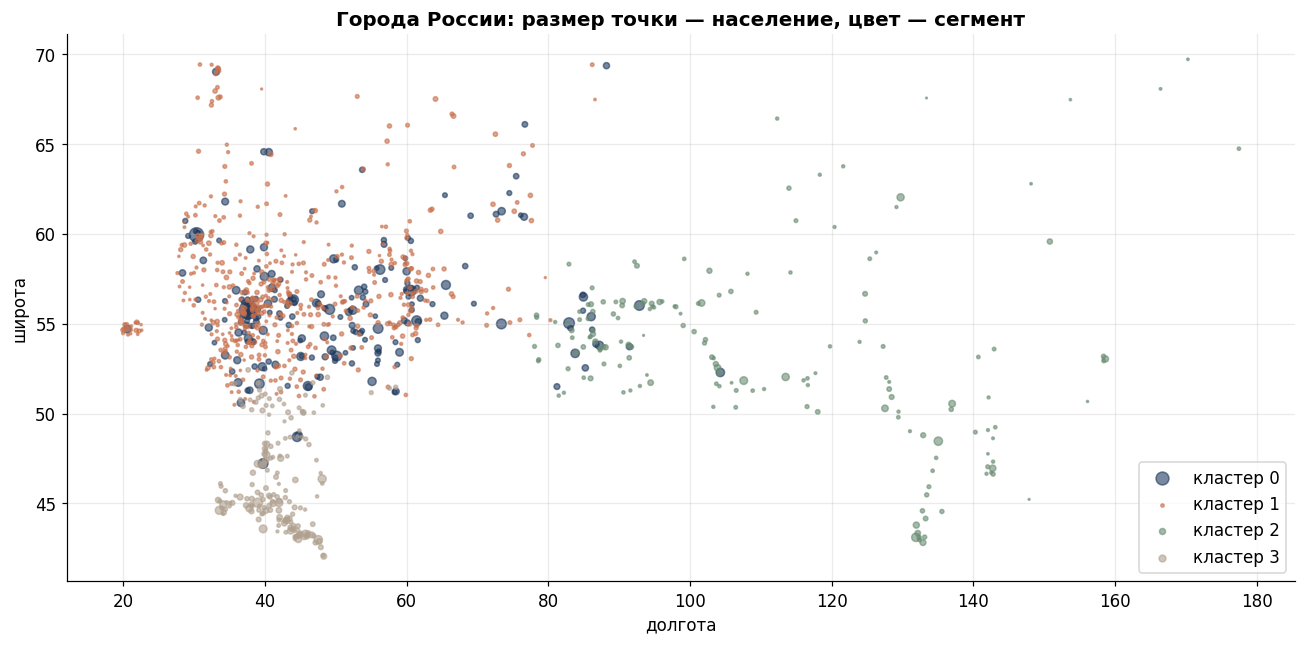

In [ ]:
plt.figure(figsize=(12,6))
for c in sorted(df["cluster"].unique()):
    sub = df[df["cluster"]==c]
    plt.scatter(sub["lon"], sub["lat"], s=np.sqrt(sub["population"])*1.2,
                color=PALETTE[c], alpha=0.6, label=f"кластер {c}")
plt.xlabel("долгота"); plt.ylabel("широта")
plt.title("Города России: размер точки — население, цвет — сегмент")
plt.legend(); plt.tight_layout(); plt.show()

## 6. Выводы

**Концентрация.** В наборе 1117 городов с суммарным населением ≈102,8 млн человек. На Москву и Санкт-Петербург приходится **17,5%** всего городского населения, на топ-10 городов — **27,5%**. Медианный город (26 тыс.) втрое меньше среднего (92 тыс.): распределение сильно перекошено вправо и в log-шкале близко к логнормальному,что является  типичной картиной для крупных стран.

**Регионы.** Городское население смещено на запад: Центральный округ (304 города, ≈30,8 млн) и Приволжский (≈19,7 млн) далеко впереди. Дальневосточный и Северо-Кавказский округа самые малочисленные по городскому населению, а средний размер города там ниже.

**Сегменты.** Города делятся на 4 естественные группы: крупные западные центры; многочисленные малые города севера и центра; восточные города (Сибирь и Дальний Восток); южные города. Москва и Петербург это статистические выбросы, поэтому кластеризацию делали по log-населению, чтобы они не искажали границы групп.

**Что проверил бы дальше:** динамику населения городов по годам (нужны панельные данные Rosstat), связь размера города с миграционным приростом, обеспеченность инфраструктурой на душу в разрезе сегментов.

## Источник данных
- Датасет: **epogrebnyak/ru-cities** — https://github.com/epogrebnyak/ru-cities (файл `assets/towns.csv`)
- Первоисточник: Rosstat, «Регионы России. Основные социально-экономические показатели городов»
- Данные реальные; расчёты и выводы — собственные.
